# Section 1 : Project Topic

This project seeks to explore the use of supervised learning within an Ecommerce Customer service satisfaction dataset. The problem that I am trying to solve here is to explore and apply the use of supervised learning models with the aim to find out:
1) how different models perform when predicting customer satisfaction
2) what drives customer satisfaction

The motivation for doing this is because in the post-COVID world, customer's preference for shopping have gone digital more than ever. The US International Trade Administration estimates that in 2024 ecommerce sales make up 22% of global retail sales, a three-fold increase from 7.4% in 2015 (International Trade Administration, 2024). With ecommerce being embedded into our lives, I wanted to learn what is top of the mind for customers who faced issues in the process of transacting through an ecommerce platform. These learnings will help me build acumen and develop a framework in understanding consumer patterns in future analysis.

**Reference:**

International Trade Administration. (2024). Impact of COVID Pandemic on eCommerce. Retrieved from [https://www.trade.gov/impact-covid-pandemic-ecommerce](https://www.trade.gov/impact-covid-pandemic-ecommerce)

In [ ]:
# @title
!pip install xgboost -q
!pip install kaggle --quiet
!pip install itables --quiet
!pip install imbalanced-learn -q

In [ ]:
# @title
import pandas as pd
import numpy as np
import os

In [ ]:
# @title
from itables import init_notebook_mode
init_notebook_mode(connected=True, all_interactive=True)

import itables.options as opt
opt.lengthMenu = [10, 25, 50, 100]

In [ ]:
# @title
os.environ["KAGGLE_KEY"] = '[YOUR OWN KAGGLE KEY]'
os.environ["KAGGLE_USERNAME"] = '[YOUR OWN KAGGLE USERNAME]'

!kaggle datasets download -d ddosad/ecommerce-customer-service-satisfaction -q
!unzip -qo ecommerce-customer-service-satisfaction.zip
df = pd.read_csv('Customer_support_data.csv')

Dataset URL: https://www.kaggle.com/datasets/ddosad/ecommerce-customer-service-satisfaction
License(s): other


In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Section 2 : Data


The source of the data is from kaggle. This is a single CSV file, where the author of the dataset explained that the customer satisfaction score data was captured over a one-month period on an anonymized ecommerced platform, and includes information about :

1. Dimensions and measurement on the interaction between the agent and customer (e.g. time of contact, time of response, etc)
2. Customer survey attributes such as dates and the score
3. Additional details related to the reason that the customer is contacting support about (e.g. the price of the item and the item category)
4. Attributes of the agent such as the tenure, the names of the agent, the supervisor and the manager


Here are some high level details on the data :

* Number of rows : 85,907
* Number of columns : 20
* Time stamp columns : [order_date_time], [Issue_reported at], [issue_responded], [Survey_response_Date]
* Numeric columns : [Item_price], [connected_handling_time], [CSAT Score]
* Categorical columns : [channel_name], [category], [Sub-category], [Customer Remarks], [Customer_City], [Product_category], [Agent_name], [Supervisor], [Manager], [Tenure Bucket], [Agent Shift]
* ID Columns : [Unique id], [Order_id]



Link to data on Kaggle : https://www.kaggle.com/datasets/ddosad/ecommerce-customer-service-satisfaction

# Section 3 : Data Cleaning

Here are some of the key data cleaning steps performed to ensure that the code runs, and we maximize the ability to obtain key inferences from the data set.

Data Type :
I have standardized the timestamp data types to `%d/%m/%Y %H:%M` for ease of calculating duration measures. For e.g. I want to know the duration of time between the survey response date against the time when the customer contacted customer support.

Column renaming :
This step is to ensure ease of debugging and reduces the chances of errors occurring. From the original data set, I opted to change all the column names to small caps and replaced spaces with underscores (_) as part of best practices in naming columns.

These are the columns with Significant proportion of NAs :
*   Customer remarks (66.5%)
*   Order ID (21.2%)
*   Order Date Time (80.0%)
*   Customer City (80.1%)
*   Product Category (80.0%)
*   Item Price (80.0%)
*   Connected Handling Time (99.7%)

I have opted to drop these columns as there are no logical ways to impute these missing values with averages at such large proportion of blanks.

Response variable :
The response variable here is a modified version of a CSAT Score (of which CSAT stands for Customer Satisfaction). The score ranges from 1-5, and scores above 4 are considered good outcomes. For ease of classification, a boolean flag was created (cast_satisfied) indicating 'true' if the CSAT score was 4 or 5.

These are some of the basic data cleaning that was done at the high level, and we would expect further iterations of data cleaning after exploring the data. This will be discussed in a later section covering the Exploratory Data Analysis.

In [ ]:
# @title
df = df.rename(columns={
    'Unique id': 'unique_id',
    'Sub-category': 'sub_category',
    'Customer Remarks': 'customer_remarks',
    'Order_id': 'order_id',
    'Issue_reported at': 'issue_reported_at',
    'issue_responded': 'survey_responded_at',
    'Survey_response_Date': 'survey_response_date',
    'Customer_City': 'customer_city',
    'Product_category': 'product_category',
    'Item_price': 'item_price',
    'Agent_name': 'agent_name',
    'Supervisor': 'supervisor',
    'Manager': 'manager',
    'Tenure Bucket': 'tenure_bucket',
    'Agent Shift': 'agent_shift',
    'CSAT Score': 'csat_score'
})

In [ ]:
# @title
# Rename the columns if needed
# Convert to datetime with dayfirst=True and specify the desired format
df['survey_responded_at'] = pd.to_datetime(df['survey_responded_at'], format='%d/%m/%Y %H:%M', dayfirst=True)
df['issue_reported_at'] = pd.to_datetime(df['issue_reported_at'], format='%d/%m/%Y %H:%M', dayfirst=True)
df['order_date_time'] = pd.to_datetime(df['order_date_time'], format='%d/%m/%Y %H:%M', dayfirst=True)

# Calculate response time in seconds
df['seconds_from_contact_to_surveyresponse'] = (df['survey_responded_at'] - df['issue_reported_at']).dt.total_seconds()
df['seconds_from_order_to_contact'] = (df['issue_reported_at'] - df['order_date_time']).dt.total_seconds()

In [ ]:
# @title
# give me a 'true' 'false' flag for [Order_id] if the field is not empty or empty (NaN / blank) call it ticket_has_order
df['ticket_has_order'] = df['order_id'].notna()
df['csat_satisfied'] = df['csat_score'] >= 4

In [ ]:
# @title
import pandas as pd

# Assuming your DataFrame is named df

# Initialize an empty list to store dictionaries containing summary information
summary_data = []

# Get the total number of rows in the DataFrame
total_rows = len(df)

# Iterate over each column in the DataFrame
for column in df.columns:
    # Determine the data type of the column
    data_type = df[column].dtype

    # Calculate the number of nulls or blanks
    nulls_blanks = df[column].isnull().sum() + df[column].eq('').sum()

    # Calculate the percentage of nulls or blanks
    percentage_nulls_blanks = round((nulls_blanks / total_rows) * 100, 1)

    # Calculate the number of rows with values
    rows_with_values = total_rows - nulls_blanks

    # Calculate the mean value if the column is numeric
    mean_value = round(df[column].mean(), 1) if pd.api.types.is_numeric_dtype(df[column]) else "-"

    # Calculate the most common value
    most_common = df[column].mode()[0] if len(df[column].mode()) > 0 else None

    # Calculate the min value if numeric and not boolean
    min_value = round(df[column].min(), 1) if pd.api.types.is_numeric_dtype(df[column]) and not pd.api.types.is_bool_dtype(df[column]) else "-"

    # Calculate the max value if numeric and not boolean
    max_value = round(df[column].max(), 1) if pd.api.types.is_numeric_dtype(df[column]) and not pd.api.types.is_bool_dtype(df[column]) else "-"

    # Append the summary information to the list
    summary_data.append({'Column': column,
                         'Data Type': str(data_type),
                         'Rows with Values': rows_with_values,
                         '% Nulls/Blanks': f"{percentage_nulls_blanks:.1f}%",
                         'Mean': mean_value,
                         'Most Common': most_common,
                         'Min': min_value,
                         'Max': max_value})

# Convert the list of dictionaries into a DataFrame
summary_df = pd.DataFrame(summary_data)

# Reorder the columns
summary_df = summary_df[['Column', 'Data Type', 'Rows with Values', '% Nulls/Blanks', 'Mean', 'Most Common', 'Min', 'Max']]

# Display the summary DataFrame
summary_df


Column       Data Type  Rows with Values  \
0                                unique_id          object             85907   
1                             channel_name          object             85907   
2                                 category          object             85907   
3                             sub_category          object             85907   
4                         customer_remarks          object             28756   
5                                 order_id          object             67675   
6                          order_date_time  datetime64[ns]             17214   
7                        issue_reported_at  datetime64[ns]             85907   
8                      survey_responded_at  datetime64[ns]             85907   
9                     survey_response_date          object             85907   
10                           customer_city          object             17079   
11                        product_category          object             17196   
12                              item_price         float64             17206   
13                 connected_handling_time         float64               242   
14                              agent_name          object             85907   
15                              supervisor          object             85907   
16                                 manager          object             85907   
17                           tenure_bucket          object             85907   
18                             agent_shift          object             85907   
19                              csat_score           int64             85907   
20  seconds_from_contact_to_surveyresponse         float64             85907   
21           seconds_from_order_to_contact         float64             17214   
22                        ticket_has_order            bool             85907   
23                          csat_satisfied            bool             85907   

   % Nulls/Blanks       Mean                           Most Common        Min  \
0            0.0%          -  0000978d-8599-4e17-8cf6-28e9faeba4c9          -   
1            0.0%          -                               Inbound          -   
2            0.0%          -                               Returns          -   
3            0.0%          -                Reverse Pickup Enquiry          -   
4           66.5%          -                                 Good           -   
5           21.2%          -  0000a850-ca65-4eb1-ace1-9e34d5d1637a          -   
6           80.0%          -                   2023-08-09 11:55:00          -   
7            0.0%          -                   2023-08-13 10:40:00          -   
8            0.0%          -                   2023-08-28 00:00:00          -   
9            0.0%          -                             28-Aug-23          -   
10          80.1%          -                             HYDERABAD          -   
11          80.0%          -                           Electronics          -   
12          80.0%     5660.8                                 999.0        0.0   
13          99.7%      462.4                                 282.0        0.0   
14           0.0%          -                          Wendy Taylor          -   
15           0.0%          -                           Carter Park          -   
16           0.0%          -                            John Smith          -   
17           0.0%          -                                   >90          -   
18           0.0%          -                               Morning          -   
19           0.0%        4.2                                     5          1   
20           0.0%     8213.2                                  60.0   -86220.0   
21          80.0%  1533993.4                              686340.0 -9192240.0   
22           0.0%        0.8                                  True          -   
23           0.0%        0.8                                  True          -   

         

# Section 4 : Exploratory Data Analysis

In [ ]:
df

unique_id channel_name         category  \
0      7e9ae164-6a8b-4521-a2d4-58f7c9fff13f      Outcall  Product Queries   
1      b07ec1b0-f376-43b6-86df-ec03da3b2e16      Outcall  Product Queries   
2      200814dd-27c7-4149-ba2b-bd3af3092880      Inbound    Order Related   
3      eb0d3e53-c1ca-42d3-8486-e42c8d622135      Inbound          Returns   
4      ba903143-1e54-406c-b969-46c52f92e5df      Inbound     Cancellation   
...                                     ...          ...              ...   
85902  505ea5e7-c475-4fac-ac36-1d19a4cb610f      Inbound   Refund Related   
85903  44b38d3f-1523-4182-aba2-72917586647c      Inbound    Order Related   
85904  723bce2c-496c-4aa8-a64b-ca17004528f0      Inbound    Order Related   
85905  707528ee-6873-4192-bfa9-a491f1c08ab5      Inbound         Feedback   
85906  07c7a878-0d5a-42e0-97ef-de59abec0238      Inbound          Returns   

                       sub_category                          customer_remarks  \
0                    Life Insurance                                       NaN   
1      Product Specific Information                                       NaN   
2                 Installation/demo                                       NaN   
3            Reverse Pickup Enquiry                                       NaN   
4                        Not Needed                                       NaN   
...                             ...                                       ...   
85902                Refund Enquiry                                       NaN   
85903        Seller Cancelled Order  Supported team customer executive   good   
85904          Order status enquiry      need to improve with proper details.   
85905      UnProfessional Behaviour                                       NaN   
85906        Reverse Pickup Enquiry                                       NaN   

                                   order_id order_date_time  \
0      c27c9bb4-fa36-4140-9f1f-21009254ffdb             NaT   
1      d406b0c7-ce17-4654-b9de-f08d421254bd             NaT   
2      c273368d-b961-44cb-beaf-62d6fd6c00d5             NaT   
3      5aed0059-55a4-4ec6-bb54-97942092020a             NaT   
4      e8bed5a9-6933-4aff-9dc6-ccefd7dcde59             NaT   
...                                     ...             ...   
85902  1b5a2b9c-a95f-405f-a42e-5b1b693f3dc9             NaT   
85903  d0e8a817-96d5-4ace-bb82-adec50398e22             NaT   
85904  bdefe788-ccec-4eda-8ca4-51045e68db8a             NaT   
85905  a031ec28-0c5e-450e-95b2-592342c40bc4             NaT   
85906  3230db30-f8da-4c44-8636-ec76d1d3d4f3             NaT   

        issue_reported_at survey_responded_at survey_response_date  ...  \
0     2023-08-01 11:13:00 2023-08-01 11:47:00            01-Aug-23  ...   
1     2023-08-01 12:52:00 2023-08-01 12:54:00            01-Aug-23  ...   
2     2023-08-01 20:16:00 2023-08-01 20:38:00            01-Aug-23  ...   
3     2023-08-01 20:56:00 2023-08-01 21:16:00            01-Aug-23  ...   
4     2023-08-01 10:30:00 2023-08-01 10:32:00            01-Aug-23  ...   
...                   ...                 ...                  ...  ...   
85902 2023-08-30 23:20:00 2023-08-31 07:22:00            31-Aug-23  ...   
85903 2023-08-31 08:15:00 2023-08-31 08:17:00            31-Aug-23  ...   
85904 2023-08-31 18:57:00 2023-08-31 19:02:00            31-Aug-23  ...   
85905 2023-08-31 19:59:00 2023-08-31 20:00:00            31-Aug-23  ...   
85906 2023-08-31 23:36:00 2023-08-31 23:37:00            31-Aug-23  ...   

                agent_name      supervisor          manager    tenure_bucket  \
0         Richard Buchanan     Mason Gupta  Jennifer Nguyen  On Job Training   
1            Vicki Collins       Dylan Kim      Michael Lee              >90   
2             Duane Norman    Jackson Park      William Kim  On Job Training   
3           Patrick Flores     Olivia Wang       John Smith              >90   
4      Christopher Sanchez  Austin Johnson      Michael Lee             0-30  

### Logging bug :
It was observed that survey responses on 2023-08-28 were all logged with timestamp 00:00:00. This would greatly impact the modeling phase as duration values would return negative. For instance, if a customer support ticket was created at 8 am on that day and the survey response time was at 2 pm, the bug on that day would cause the duration to be -8 hours, which is illogical. I chose to drop these rows, losing one day of data, which is marginal at about 2.5% of the original total.

In [ ]:
# @title
# Import pandas library
import pandas as pd

# Define the fields you want to analyze
fields = ['survey_responded_at']

# Assuming df is your DataFrame
for field in fields:
    temp_df = df[field].value_counts(dropna=False).to_frame('Count')
    temp_df['Percentage'] = df[field].value_counts(dropna=False, normalize=True).mul(100).round(2)
    print(temp_df.head())


# This reveals a day of data that logging is possibly broken

                     Count  Percentage
2023-08-28 00:00:00   3378        3.93
2023-08-27 00:00:00     21        0.02
2023-08-08 17:51:00     13        0.02
2023-08-17 11:34:00     12        0.01
2023-08-16 11:35:00     12        0.01


In [ ]:
# Drop rows where survey_responded_at = 2023-08-28 00:00:00 because of a logging bug
df = df[df['survey_responded_at'] != '2023-08-28 00:00:00']
print(len(df))

82529



### Categorical Columns to Drop :
There are customer support agent-related columns that I dropped, namely the agent name, the supervisor, and the manager. Even though these columns contain values, they are categorical variables which do not tend to be informative and actionable in predicting whether a customer will have a satisfactory outcome.


In [ ]:
# Drop columns
columns_to_drop = ['customer_remarks', 'customer_city', 'connected_handling_time',
                   'agent_name', 'supervisor', 'manager', 'order_date_time',
                   'issue_reported_at', 'survey_responded_at','order_id',
                   'survey_response_date','csat_score', 'product_category','item_price','seconds_from_order_to_contact','unique_id']
df = df.drop(columns=columns_to_drop)

### Exploring Correlation :
In this resulting dataset, there is only 1 numeric column [seconds_from_contact_to_surveyresponse], which is a proxy of how long the issue took to resolve. I plotted a logistic line against [csat_satisfied] and visually observed a good correlation, where longer issue resolution time leads to a higher odds of an unsatisfied customer. This is a promising variable, and I opted to conduct a secondary check and remove rows where the value is < 0, as negative duration values are not logically possible. This demonstrates an attempt at feature engineering, as timestamp columns are likely not useful on their own.

/Users/toshgoh/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


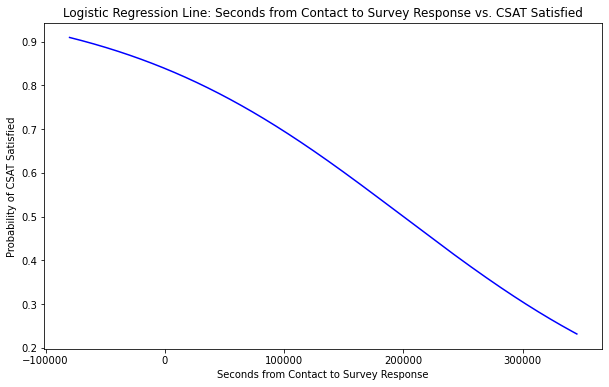

In [ ]:
# @title
# Extract the relevant columns
X = df[['seconds_from_contact_to_surveyresponse']]
y = df['csat_satisfied'].astype(int)

# Fit the logistic regression model
model = LogisticRegression()
model.fit(X, y)

# Create a range of values for plotting the logistic regression line
X_plot = np.linspace(X['seconds_from_contact_to_surveyresponse'].min(), X['seconds_from_contact_to_surveyresponse'].max(), 500).reshape(-1, 1)
y_plot = model.predict_proba(X_plot)[:, 1]

# Plot the logistic regression line
plt.figure(figsize=(10, 6))
plt.plot(X_plot, y_plot, color='b')
plt.xlabel('Seconds from Contact to Survey Response')
plt.ylabel('Probability of CSAT Satisfied')
plt.title('Logistic Regression Line: Seconds from Contact to Survey Response vs. CSAT Satisfied')
plt.show()

In [ ]:
# Drop rows where seconds_from_contact_to_response is negative
df = df[df['seconds_from_contact_to_surveyresponse'] > 0]
print(len(df))

80061



### Addressing Multicollinearity with Variance Inflation Factor (VIF) :
In order to address the issue of multicollinearity, I attempted to calculate VIF by "flattening" the categorical columns into dummy variables alongside other numeric variables. The initial VIF results show that elements from the [sub_category] column are coming up as infinity, which makes sense as it is a subset of the column [category]. I re-calculated VIF and in the second iteration, saw 3 dummy variables (category_Returns: 30.8, channel_name_Inbound: 23.7, category_Order Related: 15.8) with VIFs above 10, which is the standard for having evidence of exhibiting multicollinearity. In one more step, I dropped the 3 dummy variables and re-calculated VIF, resulting in none of the variables having a VIF of 10 or above, indicating resolved multicollinearity issues.

In [ ]:
# @title
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_encoded = pd.get_dummies(df, drop_first=True)

# Ensure boolean columns are converted to integers
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

df_encoded['ticket_has_order'] = df_encoded['ticket_has_order'].astype(int)
df_encoded['csat_satisfied'] = df_encoded['csat_satisfied'].astype(int)

In [ ]:
# @title
# Calculate VIF for each variable
vif = pd.DataFrame()
vif['VIF'] = [variance_inflation_factor(df_encoded.values, i) for i in range(df_encoded.shape[1])]
vif['Variable'] = df_encoded.columns
vif

/Users/toshgoh/opt/anaconda3/lib/python3.9/site-packages/statsmodels/stats/outliers_influence.py:193: RuntimeWarning: divide by zero encountered in double_scalars
  vif = 1. / (1. - r_squared_i)


VIF                                Variable
0   1.030733  seconds_from_contact_to_surveyresponse
1   1.018096                        ticket_has_order
2   1.057012                          csat_satisfied
3   5.079324                    channel_name_Inbound
4   5.116817                    channel_name_Outcall
..       ...                                     ...
75  2.290473           tenure_bucket_On Job Training
76  4.509316                     agent_shift_Evening
77  4.431861                     agent_shift_Morning
78  1.221855                       agent_shift_Night
79  1.579876                       agent_shift_Split

[80 rows x 2 columns]

In [ ]:
# @title
# Drop columns
columns_to_drop = ['sub_category']
df = df.drop(columns=columns_to_drop)

In [ ]:
# @title
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_encoded = pd.get_dummies(df, drop_first=True)

# Ensure boolean columns are converted to integers
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

df_encoded['ticket_has_order'] = df_encoded['ticket_has_order'].astype(int)
df_encoded['csat_satisfied'] = df_encoded['csat_satisfied'].astype(int)

# Calculate VIF for each variable
vif = pd.DataFrame()
vif['VIF'] = [variance_inflation_factor(df_encoded.values, i) for i in range(df_encoded.shape[1])]
vif['Variable'] = df_encoded.columns
vif

VIF                                Variable
0    1.129279  seconds_from_contact_to_surveyresponse
1    4.562820                        ticket_has_order
2    5.776087                          csat_satisfied
3   23.723737                    channel_name_Inbound
4    5.912846                    channel_name_Outcall
5    2.443496                   category_Cancellation
6    2.488981                       category_Feedback
7    1.313980              category_Offers & Cashback
8    1.040667             category_Onboarding related
9   15.821901                  category_Order Related
10   1.062698                         category_Others
11   2.545197               category_Payments related
12   3.529439                category_Product Queries
13   3.842367                 category_Refund Related
14  30.819301                        category_Returns
15   2.882833              category_Shopzilla Related
16   2.065107                     tenure_bucket_31-60
17   1.682685                     tenure_bucket_61-90
18   3.956793                       tenure_bucket_>90
19   3.197732           tenure_bucket_On Job Training
20   7.296373                     agent_shift_Evening
21   8.385194                     agent_shift_Morning
22   1.236671                       agent_shift_Night
23   1.640155                       agent_shift_Split

In [ ]:
# @title
columns_to_drop = ['category_Returns','channel_name_Inbound','category_Order Related']
df_encoded = df_encoded.drop(columns=columns_to_drop)

In [ ]:
# @title
# Calculate VIF for each variable
vif = pd.DataFrame()
vif['VIF'] = [variance_inflation_factor(df_encoded.values, i) for i in range(df_encoded.shape[1])]
vif['Variable'] = df_encoded.columns
vif

VIF                                Variable
0   1.118974  seconds_from_contact_to_surveyresponse
1   4.099423                        ticket_has_order
2   4.842429                          csat_satisfied
3   1.214340                    channel_name_Outcall
4   1.032739                   category_Cancellation
5   1.033324                       category_Feedback
6   1.007677              category_Offers & Cashback
7   1.001111             category_Onboarding related
8   1.001927                         category_Others
9   1.035350               category_Payments related
10  1.057261                category_Product Queries
11  1.066352                 category_Refund Related
12  1.042274              category_Shopzilla Related
13  1.790379                     tenure_bucket_31-60
14  1.490863                     tenure_bucket_61-90
15  2.934994                       tenure_bucket_>90
16  2.765834           tenure_bucket_On Job Training
17  4.104236                     agent_shift_Evening
18  4.440619                     agent_shift_Morning
19  1.135442                       agent_shift_Night
20  1.388029                       agent_shift_Split

### Response variable and imbalance check :
However, there are indications of an imbalance as 82.2% of the response variable reported 'True'. This is because in the original set, there are already ~70% of responses reporting a 5 in the CSAT score. We will approach the modeling phase with the imbalance in mind.

In [ ]:
# @title
# Import pandas library
import pandas as pd

# Define the fields you want to analyze
fields = ['csat_satisfied']

# Assuming df is your DataFrame
for field in fields:
    temp_df = df[field].value_counts(dropna=False).to_frame('Count')
    temp_df['Percentage'] = df[field].value_counts(dropna=False, normalize=True).mul(100).round(2)
    print(temp_df)
    print()

       Count  Percentage
True   65777       82.16
False  14284       17.84



### Addressing multicollinearity :

Based on the Variance Inflation Factor (VIF), there is no significant evidence of multicollinearity within the dataset after the EDA anc data cleaning above.

It is important to note that multicollinearity can impact the performance of regression models, and its effects are more pronounced in logistic regression than in gradient boosting. This is because logistic regression relies on the estimation of regression coefficients, and multicollinearity can inflate the standard errors of these coefficients, leading to instability in the model estimates and potentially affecting the interpretation of the coefficients.

To mitigate the potential impact of multicollinearity and ensure a fair comparison between logistic regression and gradient boosting models, I addressed the issue by dropping dummy variables with high VIF. By removing these variables, which are likely to be highly correlated with other predictors, we can reduce the risk of multicollinearity and ensure that both models are evaluated on a similar basis. This approach allows for a more accurate comparison of the predictive performance of logistic regression and gradient boosting models.

<br>

### Model Selection :

The next step is to consider the models that are potentially appropriate for the problem we are trying to solve. To reiterate, we aim to:

#### Objectives
1. Evaluate the performance of different models in predicting customer satisfaction
2. Identify the key drivers of customer satisfaction

#### For supervised learning, we will consider:
1. Logistic Regression Model, which predicts the log of odds via multiple linear regression
2. Gradient Boosting Model, which uses decision trees to predict the outcome by combining multiple weak models

<br>

### Hyperparameter tuning :

A range of hyperparameters will be used to tune the models and determine which combination produces the best results. We have opted to use the following values to find the most optimal model:
1. n_estimators : 5, 6, 7, 8, 9, 10, 11, 12, 13
2. learning_rate = 0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0
3. max_depth = 2, 3, 4, 5, 6

Cross-validation will be used to assess the models' performance on different subsets of data and select the optimal set of hyperparameters. We will explore 3, 5, and 10-fold settings to determine which has better model performance.

To address the issue of an imbalance in the response variable (Customer satisfaction), we will explore:
1. Synthetic Minority Oversampling Technique (SMOTE) to oversample the minority class variable (csat_satisfied = false), aiming to balance the class distribution without including additional features
2. Modifying class weights (via scale_pos_weight) to scale errors on the imbalanced minority class (csat_satisfied = false) and encourage the model to over-correct them

# Split X and Y to train and test data sets

In [ ]:
# Load your dataset

# data = df.copy()
data = df_encoded.copy()

# Splitting data into features (X) and target variable (y)
X = data.drop('csat_satisfied', axis=1)
y = data['csat_satisfied']

# Separate numerical and categorical columns
numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Splitting processed data into train and test sets (70:30 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Calculate class distribution
class_distribution = y_train.value_counts()

# Calculate ratio of negative to positive class
ratio_neg_to_pos = class_distribution[0] / class_distribution[1]

## Gradient Boosting Model

In [ ]:
# @title
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
import time
import pandas as pd

# Define hyperparameters for tuning
xgb_params = {
    'n_estimators': [5, 6, 7, 8, 9, 10, 11, 12, 13],
    'learning_rate': [0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0],
    'max_depth': [2, 3, 4, 5, 6]
}

# Try different CV values
cv_values = [3,5,10]

# Define model variants
model_variants = ['XGBoost model', 'XGBoost model with SMOTE', 'XGBoost model with scale_pos_weight']

# Store results in a list of tuples
results = []

# Loop through model variants
for variant in model_variants:
    print(f"\nModel Variant: {variant}")

    # Loop through CV values
    for cv in cv_values:
        print(f"CV: {cv} ",end=" ")

        # Initialize StratifiedKFold for cross-validation
        skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

        # Initialize XGBoost model based on variant
        if variant == 'XGBoost model with scale_pos_weight':
            xgb_model = xgb.XGBClassifier(scale_pos_weight=ratio_neg_to_pos)
        elif variant == 'XGBoost model with SMOTE':
            smote = SMOTE()
            xgb_model = xgb.XGBClassifier()
        else:
            xgb_model = xgb.XGBClassifier()

        # Initialize GridSearchCV
        grid = GridSearchCV(estimator=xgb_model, param_grid=xgb_params, cv=skf, scoring='accuracy')

        # Start timing
        start_time = time.time()

        # Fit the model
        grid.fit(X_train, y_train)

        # Calculate mean accuracy across all folds
        mean_accuracy = grid.best_score_

        # Calculate time taken
        end_time = time.time()
        time_taken = end_time - start_time  # Time taken in seconds

        # Convert time taken to minutes and seconds
        mins = int(time_taken // 60)
        secs = int(time_taken % 60)

        # Print CV and time taken
        print(f"; Time taken: {mins} minutes {secs} seconds")

        # Calculate confusion matrix and classification report
        y_pred = grid.predict(X_test)
        conf_matrix = confusion_matrix(y_test, y_pred)
        class_rep = classification_report(y_test, y_pred, output_dict=True)

        # Store results in a tuple
        result_tuple = (
            variant,
            cv,
            grid.best_params_,
            grid.best_score_,
            mean_accuracy,
            conf_matrix,
            class_rep
        )

        results.append(result_tuple)

# Now you have the results stored in the `results` list


Model Variant: XGBoost model
CV: 3  ; Time taken: 0 minutes 54 seconds
CV: 5  ; Time taken: 1 minutes 35 seconds
CV: 10  ; Time taken: 3 minutes 29 seconds

Model Variant: XGBoost model with SMOTE
CV: 3  ; Time taken: 0 minutes 52 seconds
CV: 5  ; Time taken: 1 minutes 36 seconds
CV: 10  ; Time taken: 3 minutes 33 seconds

Model Variant: XGBoost model with scale_pos_weight
CV: 3  ; Time taken: 0 minutes 55 seconds
CV: 5  ; Time taken: 1 minutes 39 seconds
CV: 10  ; Time taken: 3 minutes 58 seconds


In [ ]:
# @title
import pandas as pd

# Create a list to store the results
results_list = []

# Iterate over results and append to the list
for result in results:
    # Unpack the result tuple
    variant, cv, best_params, best_score, mean_accuracy, conf_matrix, class_report = result

    # Flatten the class_report dictionary
    class_report_flat = {}
    for label, metrics in class_report.items():
        if isinstance(metrics, dict):
            for metric, value in metrics.items():
                class_report_flat[f"{label}_{metric}"] = value
        else:
            class_report_flat[label] = metrics

    # Create a dictionary for the row
    row = {
        'Model Variant': variant,
        'CV': cv,
        'Best Parameters Found': best_params,
        'Best Score': best_score,
        'Accuracy Score': mean_accuracy,
        'Confusion Matrix': conf_matrix,
        **class_report_flat  # Unpack the flattened class_report dictionary
    }

    # Append the row to the results list
    results_list.append(row)

# Create a DataFrame from the results list
results_df = pd.DataFrame(results_list)

# Display the DataFrame
display(results_df)


Model Variant  CV  \
0                        XGBoost model   3   
1                        XGBoost model   5   
2                        XGBoost model  10   
3             XGBoost model with SMOTE   3   
4             XGBoost model with SMOTE   5   
5             XGBoost model with SMOTE  10   
6  XGBoost model with scale_pos_weight   3   
7  XGBoost model with scale_pos_weight   5   
8  XGBoost model with scale_pos_weight  10   

                               Best Parameters Found  Best Score  \
0  {'learning_rate': 1.25, 'max_depth': 2, 'n_est...    0.822098   
1  {'learning_rate': 0.75, 'max_depth': 2, 'n_est...    0.822080   
2  {'learning_rate': 1.0, 'max_depth': 4, 'n_esti...    0.822062   
3  {'learning_rate': 1.25, 'max_depth': 2, 'n_est...    0.822098   
4  {'learning_rate': 0.75, 'max_depth': 2, 'n_est...    0.822080   
5  {'learning_rate': 1.0, 'max_depth': 4, 'n_esti...    0.822062   
6  {'learning_rate': 2.0, 'max_depth': 4, 'n_esti...    0.674424   
7  {'learning_rate': 2.0, 'max_depth': 2, 'n_esti...    0.654652   
8  {'learning_rate': 1.25, 'max_depth': 6, 'n_est...    0.637754   

   Accuracy Score               Confusion Matrix  0_precision  0_recall  \
0        0.822098      [[64, 4226], [90, 19639]]     0.415584  0.014918   
1        0.822080      [[18, 4272], [16, 19713]]     0.529412  0.004196   
2        0.822062      [[37, 4253], [40, 19689]]     0.480519  0.008625   
3        0.822098      [[64, 4226], [90, 19639]]     0.415584  0.014918   
4        0.822080      [[18, 4272], [16, 19713]]     0.529412  0.004196   
5        0.822062      [[37, 4253], [40, 19689]]     0.480519  0.008625   
6        0.674424  [[1610, 2680], [7999, 11730]]     0.167551  0.375291   
7        0.654652  [[3170, 1120], [12052, 7677]]     0.208251  0.738928   
8        0.637754  [[2393, 1897], [6865, 12864]]     0.258479  0.557809   

   0_f1-score  0_support  ...  1_support  accuracy  macro avg_precision  \
0    0.028803     4290.0  ...    19729.0  0.820309             0.619253   
1    0.008326     4290.0  ...    19729.0  0.821475             0.675650   
2    0.016945     4290.0  ...    19729.0  0.821266             0.651441   
3    0.028803     4290.0  ...    19729.0  0.820309             0.619253   
4    0.008326     4290.0  ...    19729.0  0.821475             0.675650   
5    0.016945     4290.0  ...    19729.0  0.821266             0.651441   
6    0.231671     4290.0  ...    19729.0  0.555394             0.490785   
7    0.324928     4290.0  ...    19729.0  0.451601             0.540468   
8    0.353262     4290.0  ...    19729.0  0.635205             0.564982   

   macro avg_recall  macro avg_f1-score  macro avg_support  \
0          0.505178            0.464899            24019.0   
1          0.501692            0.455117            24019.0   
2          0.503299            0.459321            24019.0   
3          0.505178            0.464899            24019.0   
4          0.501692            0.455117            24019.0   
5          0.503299            0.459321            24019.0   
6          0.484924            0.459431            24019.0   
7          0.564025            0.431587            24019.0   
8          0.604922            0.549609            24019.0   

   weighted avg_precision  weighted avg_recall  weighted avg_f1-score  \
0                0.750167             0.820309               0.745214   
1                0.769650             0.821475               0.742306   
2                0.761306             0.821266               0.743673   
3                0.750167             0.820309               0.745214   
4                0.769650             0.821475               0.742306   
5                0.761306             0.821266               0.743673   
6                0.698554             0.555394               0.605831   
7                0.754010             0.451601               0.500145   
8                0.761997             0.635205               0.675817   

   weighted avg_support  
0  

In [ ]:
# @title
# Selecting the desired columns from the DataFrame
desired_columns = [
    'Model Variant',
    'CV',
    'Best Parameters Found',
    'Best Score',
    'Confusion Matrix',
    'macro avg_f1-score',
    '0_f1-score',
    '1_f1-score']

# Filtering rows where the CV values are 3, 5, or 10
filtered_results_df = results_df[results_df["CV"].isin([3, 5, 10])]

# Creating a new DataFrame with only the desired columns
desired_results_df = filtered_results_df[desired_columns]

# Displaying the new DataFrame
display(desired_results_df)


Model Variant  CV  \
0                        XGBoost model   3   
1                        XGBoost model   5   
2                        XGBoost model  10   
3             XGBoost model with SMOTE   3   
4             XGBoost model with SMOTE   5   
5             XGBoost model with SMOTE  10   
6  XGBoost model with scale_pos_weight   3   
7  XGBoost model with scale_pos_weight   5   
8  XGBoost model with scale_pos_weight  10   

                               Best Parameters Found  Best Score  \
0  {'learning_rate': 1.25, 'max_depth': 2, 'n_est...    0.822098   
1  {'learning_rate': 0.75, 'max_depth': 2, 'n_est...    0.822080   
2  {'learning_rate': 1.0, 'max_depth': 4, 'n_esti...    0.822062   
3  {'learning_rate': 1.25, 'max_depth': 2, 'n_est...    0.822098   
4  {'learning_rate': 0.75, 'max_depth': 2, 'n_est...    0.822080   
5  {'learning_rate': 1.0, 'max_depth': 4, 'n_esti...    0.822062   
6  {'learning_rate': 2.0, 'max_depth': 4, 'n_esti...    0.674424   
7  {'learning_rate': 2.0, 'max_depth': 2, 'n_esti...    0.654652   
8  {'learning_rate': 1.25, 'max_depth': 6, 'n_est...    0.637754   

                Confusion Matrix  macro avg_f1-score  0_f1-score  1_f1-score  
0      [[64, 4226], [90, 19639]]            0.464899    0.028803    0.900996  
1      [[18, 4272], [16, 19713]]            0.455117    0.008326    0.901908  
2      [[37, 4253], [40, 19689]]            0.459321    0.016945    0.901697  
3      [[64, 4226], [90, 19639]]            0.464899    0.028803    0.900996  
4      [[18, 4272], [16, 19713]]            0.455117    0.008326    0.901908  
5      [[37, 4253], [40, 19689]]            0.459321    0.016945    0.901697  
6  [[1610, 2680], [7999, 11730]]            0.459431    0.231671    0.687191  
7  [[3170, 1120], [12052, 7677]]            0.431587    0.324928    0.538246  
8  [[2393, 1897], [6865, 12864]]            0.549609    0.353262    0.745955

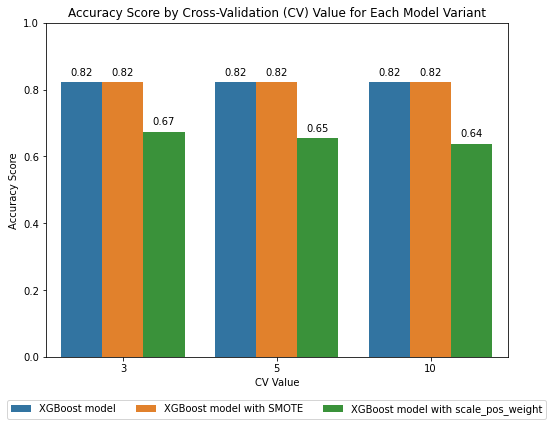

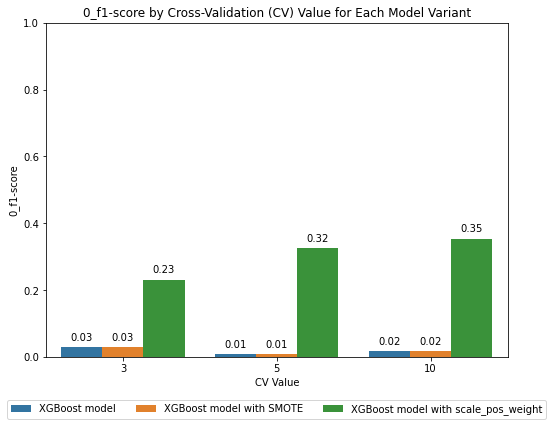

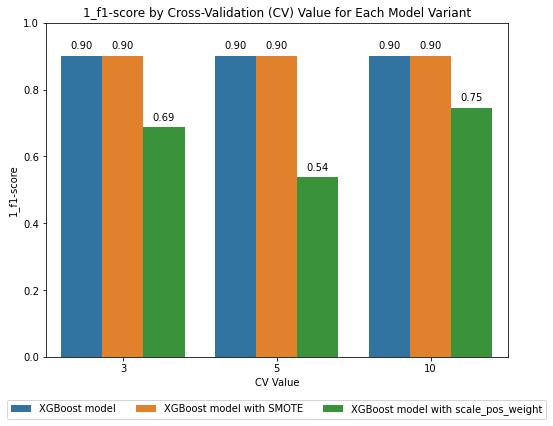

In [ ]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

# Define the metrics to plot
metrics = ['Accuracy Score', '0_f1-score', '1_f1-score']

# Create separate plots for each metric
for metric in metrics:
    # Group results by Model Variant and CV values and calculate mean metric value
    metric_by_variant_cv = results_df.groupby(['Model Variant', 'CV'])[metric].mean().reset_index()

    # Plot metric by CV for each model variant
    plt.figure(figsize=(8, 6))
    sns.barplot(data=metric_by_variant_cv, x='CV', y=metric, hue='Model Variant')
    plt.title(f'{metric} by Cross-Validation (CV) Value for Each Model Variant')
    plt.xlabel('CV Value')
    plt.ylabel(metric)
    plt.ylim(0, 1)  # Set y-axis scale from 0 to 1

    # Add labels on top of the bars
    for patch in plt.gca().patches:
        plt.gca().annotate(f"{patch.get_height():.2f}", (patch.get_x() + patch.get_width() / 2., patch.get_height()),
                           ha='center', va='center', xytext=(0, 10), textcoords='offset points')

    # Move legend to the bottom and spread horizontally
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(metric_by_variant_cv['Model Variant'].unique()))

    plt.tight_layout()
    plt.show()


## Logistic Regression and Results

In [ ]:
# @title
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import time

# Define hyperparameters for tuning
logreg_params = {
    'C': [0.01, 0.1, 1, 10, 100],  # Regularization parameter
    'solver': ['liblinear', 'lbfgs'],  # Different solvers for logistic regression
    'max_iter': [1000]  # Increase the number of iterations
}

cv_values = [3,5,10]

# Store results for logistic regression
logreg_results = []

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Loop through CV values
for cv in cv_values:
    print(f"Logistic Regression CV: {cv}", end=" ")

    # Initialize StratifiedKFold for cross-validation
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    # Initialize Logistic Regression model
    logreg_model = LogisticRegression(random_state=42)

    # Initialize GridSearchCV
    grid = GridSearchCV(estimator=logreg_model, param_grid=logreg_params, cv=skf, scoring='accuracy')

    # Start timing
    start_time = time.time()

    # Fit the model
    grid.fit(X_train_scaled, y_train)

    # Calculate mean accuracy across all folds
    mean_accuracy = grid.best_score_

    # Calculate time taken
    end_time = time.time()
    time_taken = end_time - start_time  # Time taken in seconds

    # Convert time taken to minutes and seconds
    mins = int(time_taken // 60)
    secs = int(time_taken % 60)

    # Print CV and time taken
    print(f"; Time taken: {mins} minutes {secs} seconds")

    # Calculate confusion matrix and classification report
    y_pred = grid.predict(X_test_scaled)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_rep = classification_report(y_test, y_pred, output_dict=True)

    # Store results in a tuple
    result_tuple = (
        'Logistic Regression',
        cv,
        grid.best_params_,
        grid.best_score_,
        mean_accuracy,
        conf_matrix,
        class_rep
    )

    logreg_results.append(result_tuple)

# Now you have the logistic regression results stored in the `logreg_results` list


Logistic Regression CV: 3 ; Time taken: 0 minutes 0 seconds
Logistic Regression CV: 5 ; Time taken: 0 minutes 1 seconds
Logistic Regression CV: 10 ; Time taken: 0 minutes 3 seconds


In [ ]:
# @title
import pandas as pd

# Create a list to store the results
logreg_results_list = []

# Iterate over logreg_results and append to the list
for result in logreg_results:
    # Unpack the result tuple
    variant, cv, best_params, best_score, mean_accuracy, conf_matrix, class_report = result

    # Flatten the class_report dictionary
    class_report_flat = {}
    for label, metrics in class_report.items():
        if isinstance(metrics, dict):
            for metric, value in metrics.items():
                class_report_flat[f"{label}_{metric}"] = value
        else:
            class_report_flat[label] = metrics

    # Create a dictionary for the row
    row = {
        'Model Variant': variant,
        'CV': cv,
        'Best Parameters Found': best_params,
        'Best Score': best_score,
        'Accuracy Score': mean_accuracy,
        'Confusion Matrix': conf_matrix,
        **class_report_flat  # Unpack the flattened class_report dictionary
    }

    # Append the row to the results list
    logreg_results_list.append(row)

# Create a DataFrame from the results list
logreg_results_df = pd.DataFrame(logreg_results_list)

# Display the DataFrame
display(logreg_results_df)


Model Variant  CV                             Best Parameters Found  \
0  Logistic Regression   3  {'C': 0.01, 'max_iter': 1000, 'solver': 'lbfgs'}   
1  Logistic Regression   5  {'C': 0.01, 'max_iter': 1000, 'solver': 'lbfgs'}   
2  Logistic Regression  10  {'C': 0.01, 'max_iter': 1000, 'solver': 'lbfgs'}   

   Best Score  Accuracy Score             Confusion Matrix  0_precision  \
0    0.820831        0.820831  [[106, 4184], [122, 19607]]     0.464912   
1    0.820920        0.820920  [[106, 4184], [122, 19607]]     0.464912   
2    0.820867        0.820867  [[106, 4184], [122, 19607]]     0.464912   

   0_recall  0_f1-score  0_support  ...  1_support  accuracy  \
0  0.024709    0.046923     4290.0  ...    19729.0  0.820725   
1  0.024709    0.046923     4290.0  ...    19729.0  0.820725   
2  0.024709    0.046923     4290.0  ...    19729.0  0.820725   

   macro avg_precision  macro avg_recall  macro avg_f1-score  \
0             0.644524          0.509262             0.47399   
1             0.644524          0.509262             0.47399   
2             0.644524          0.509262             0.47399   

   macro avg_support  weighted avg_precision  weighted avg_recall  \
0            24019.0                0.759975             0.820725   
1            24019.0                0.759975             0.820725   
2            24019.0                0.759975             0.820725   

   weighted avg_f1-score  weighted avg_support  
0               0.748501               24019.0  
1               0.748501               24019.0  
2               0.748501               24019.0  

[3 rows x 23 columns]

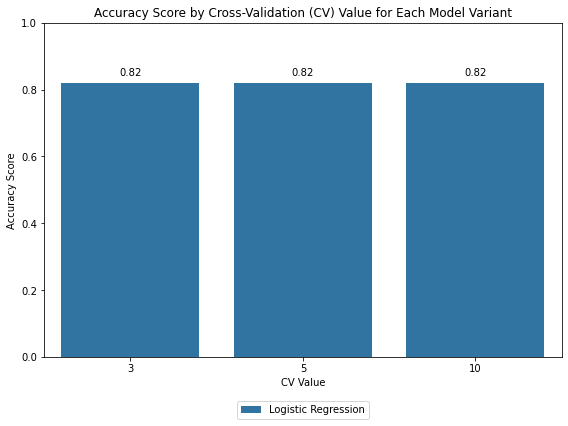

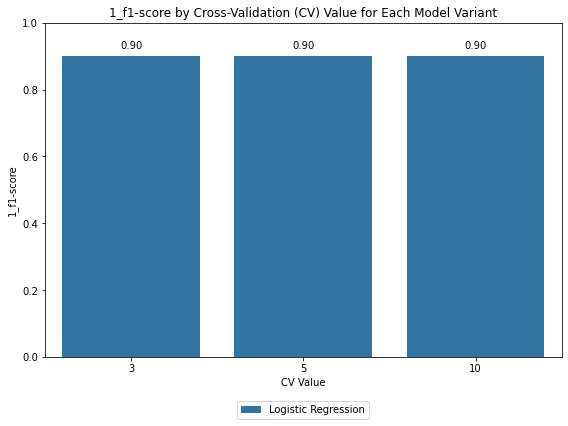

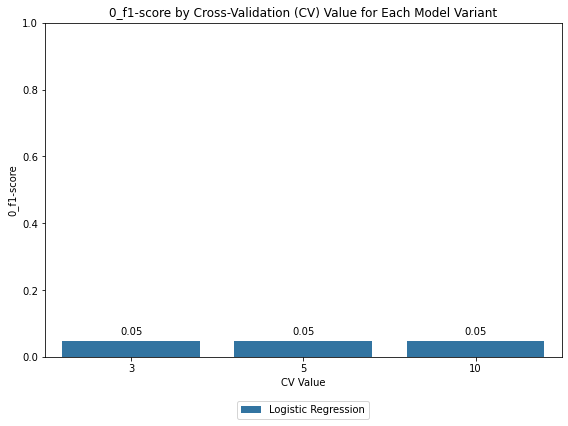

In [ ]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

# Define the metrics to plot
metrics = ['Accuracy Score', '1_f1-score', '0_f1-score']

# Create separate plots for each metric
for metric in metrics:
    # Group results by Model Variant and CV values and calculate mean metric value
    metric_by_variant_cv = logreg_results_df.groupby(['Model Variant', 'CV'])[metric].mean().reset_index()

    # Plot metric by CV for each model variant
    plt.figure(figsize=(8, 6))
    sns.barplot(data=metric_by_variant_cv, x='CV', y=metric, hue='Model Variant')
    plt.title(f'{metric} by Cross-Validation (CV) Value for Each Model Variant')
    plt.xlabel('CV Value')
    plt.ylabel(metric)
    plt.ylim(0, 1)  # Set y-axis scale from 0 to 1

    # Add labels on top of the bars
    for patch in plt.gca().patches:
        plt.gca().annotate(f"{patch.get_height():.2f}", (patch.get_x() + patch.get_width() / 2., patch.get_height()),
                           ha='center', va='center', xytext=(0, 10), textcoords='offset points')

    # Move legend to the bottom and spread horizontally
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(metric_by_variant_cv['Model Variant'].unique()))

    plt.tight_layout()
    plt.show()


In [ ]:
# @title
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Assuming X_train, y_train, X_test, and y_test are already defined
# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define best hyperparameters for tuning
best_logreg_params = {
    'C': 0.01,  # Best regularization parameter from previous tuning
    'solver': 'lbfgs',  # Best solver from previous tuning
    'max_iter': 1000  # Increased number of iterations
}

# Initialize Logistic Regression model with best parameters
best_logreg_model = LogisticRegression(**best_logreg_params, random_state=42)

# Fit the model
best_logreg_model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred = best_logreg_model.predict(X_test_scaled)

# Extract the intercept and coefficients
intercept = best_logreg_model.intercept_[0]
coefficients = best_logreg_model.coef_[0]
feature_names = X_train.columns
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Print the summary
print("Logistic Regression Coefficients")
display(coef_df)


Logistic Regression Coefficients


Feature  Coefficient
0   seconds_from_contact_to_surveyresponse    -0.273964
1                         ticket_has_order    -0.036904
2                     channel_name_Outcall     0.030011
3                    category_Cancellation    -0.062941
4                        category_Feedback    -0.040419
5               category_Offers & Cashback     0.000670
6              category_Onboarding related    -0.004929
7                          category_Others    -0.043572
8                category_Payments related     0.029514
9                 category_Product Queries    -0.075642
10                 category_Refund Related    -0.009851
11              category_Shopzilla Related     0.008006
12                     tenure_bucket_31-60     0.012176
13                     tenure_bucket_61-90     0.021360
14                       tenure_bucket_>90     0.005899
15           tenure_bucket_On Job Training    -0.092789
16                     agent_shift_Evening     0.023347
17                     agent_shift_Morning    -0.061339
18                       agent_shift_Night    -0.009724
19                       agent_shift_Split     0.052225

### Feature importance :

I had a preliminary look at using a regular XGBoost model and observed the relative importance of the features. Visually, the [seconds_from_contact_to_surveyresponse] feature had a significant lead in terms of relative importance, indicating that it is a crucial variable in predicting customer satisfaction. We will discuss feature importance in more detail in the results section.

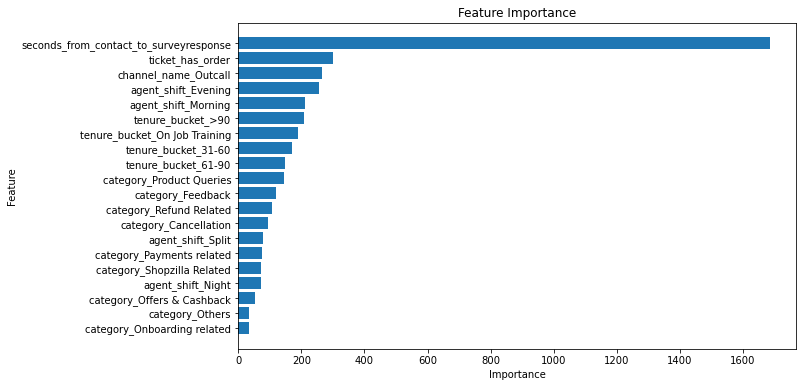

In [ ]:
# @title
# Initialize and train the XGBoost classifier
import xgboost as xgb
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

# Feature importance
importance = model.get_booster().get_score(importance_type='weight')
importance_df = pd.DataFrame(importance.items(), columns=['Feature', 'Importance']).sort_values(by='Importance', ascending=True)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()

# Section 6 : Results and analysis

In assessing the performance of various model variants, I conducted a comprehensive comparison to elucidate their efficacy. Presenting here is a succinct overview of the findings, emphasizing the selection of the optimal model variant based on cross-validation (CV) scores. For clarity, the comparative analysis is illustrated through accompanying plots.

Evaluation Metrics:
1. Model Score: Reflects the overall accuracy of the model in predicting outcomes.
2. F1-Score for csat_satisfied = True/False: Provides a nuanced assessment of the model's predictive capability for both positive and negative outcomes of the response variable, csat_satisfied. Given the skewness observed in the dataset, particularly towards 'True' outcomes, this metric offers insight into potential disparities in predictive performance.

<br>

### Model Performance Summary

| Model Variant                       | CV  | Best Parameters Found                                        | Model Performance Score | Confusion Matrix              | macro_f1-score | csat_satisfied = False_f1-score | csat_satisfied = True_f1-score |
|-------------------------------------|-----|--------------------------------------------------------------|------------|------------------------------|------------------------------|----------------------------|---------------------------|
| XGBoost model                       | 3   | {'learning_rate': 1.25, 'max_depth': 2, 'n_estimators': 11}    | 0.822098   | [[64, 4226], [90, 19639]]    | 0.464899                   | 0.028803                   | 0.900996                  |
| XGBoost model with SMOTE            | 3   | {'learning_rate': 1.25, 'max_depth': 2, 'n_estimators': 11}    | 0.822098   | [[64, 4226], [90, 19639]]    | 0.464899                   | 0.028803                   | 0.900996                  |
| XGBoost model with scale_pos_weight | 10   | {'learning_rate': 1.25, 'max_depth': 6, 'n_estimators': 12}   | 0.637754    | [2393, 1897], [6865, 12864]] | 0.549609                   | 0.353262                   | 0.745955                  |
| Logistic Regression	              | 5   | {'C': 0.01, 'max_iter': 1000, 'solver': 'lbfgs'}             | 0.82092	| [[106, 4184], [122, 19607]]  | 0.47399	                 | 0.046923	                | 0.901057	                |

(For visualizations please refer to above cells)

<br>


### Choice of model

After iterating across different model variants and tuning with a range of hyperparameters, I have ultimately landed on the "**XGBoost Model with scale_pos_weight**" as the one model I would use to predict customer satisfaction.

This is in spite of the lower overall model performance score at 0.63 compared to other candidates at 0.82. This decision is driven by a deeper evaluation of the F1-scores for csat_satisfied = true/false separately, revealing that the class imbalance of csat_satisfied (skewed towards 'True') has significantly reduced predictive power for csat_satisfied = false.

To address this imbalance, I implemented techniques like SMOTE and adjusted the model's error scaling via the "scale_pos_weight" setting. Implementing XGBoost with scale_pos_weight has resulted in a more balanced accuracy, where the F1-score for the minority class (csat_satisfied = false) is 0.35, compared to the other models which ranged between 0.02 and 0.05.

Despite the reduction in the F1-score for the majority class (csat_satisfied = true) from 0.90 to 0.75, I still believe this model is preferable because:


*   Balanced Performance: The model with scale_pos_weight provides a more balanced performance across both classes. This is also showcased by the macro F1-scores, where this model has the highest score amongst other comparison models. In practical applications, this means that the model is better at identifying instances where customers are not satisfied, which is crucial for proactive customer service and retention strategies.

*   Addressing Class Imbalance: The F1-score for the minority class is significantly improved, indicating that the model is more capable of detecting dissatisfied customers. This is critical in customer satisfaction models where identifying dissatisfaction early can lead to interventions that improve overall customer experience.

*   Business Impact: Misclassifying dissatisfied customers as satisfied can have a more detrimental impact on business than the reverse. By improving the model's sensitivity to dissatisfaction, the business can better address issues and reduce churn, ultimately leading to a more loyal customer base.

*   Strategic Decisions: For strategic decision-making, understanding and accurately predicting dissatisfaction is more valuable than a marginal improvement in overall accuracy. The insights gained from a balanced model can inform targeted actions that specifically address pain points.

In summary, while the "**XGBoost Model with scale_pos_weight**" shows a lower overall performance score, its ability to better detect dissatisfied customers justifies its use. The improved F1-score for the minority class makes it a more practical choice for applications where understanding and mitigating customer dissatisfaction is crucial. This balanced approach ensures that the model provides actionable insights that can drive meaningful improvements in customer satisfaction and business outcomes.



# Section 7 : Discussion and Conclusion

### Learning and Takeaways
Throughout this project, I gained significant insights into the application and implementation of supervised learning models, particularly logistic regression and gradient boosting, to predict customer satisfaction based on various features. This hands-on experience deepened my understanding of how to effectively use these models to derive meaningful predictions.

I also learned the importance of data cleaning and multicollinearity checks, ensuring that the inputs fed into the model generate accurate and reliable outputs. By addressing multicollinearity, I ensured that the models were not misled by highly correlated features, which could have skewed the results.

Feature engineering emerged as a crucial step in this process, helping to identify additional potential features that could improve the model's predictive power. One significant outcome of this was the creation of the 'seconds_from_contact_to_surveyresponse' feature. When analyzing feature importance, this newly engineered feature turned out to be the most significant predictor of customer satisfaction.

While the XGBoost model excels at ranking feature importance, it doesn't provide insights into the direction of the relationship. To augment this analysis, I used logistic regression, which revealed that the 'seconds_from_contact_to_surveyresponse' feature has a coefficient of -0.282448. This indicates that a shorter time to resolve customer issues increases the likelihood of achieving customer satisfaction. In other words, quicker responses to customer queries lead to higher satisfaction rates. Converting the coefficient to probability, the interpretation is that a unit reduction in resolution time leads to a 0.04 increase in probability for a good customer satisfaction outcome.

<br>

### Why Something Didn't Work
A persistent challenge throughout this project was the issue of class imbalance. The dataset was heavily skewed towards customers who reported being satisfied, which negatively impacted the model's performance, particularly the F1-score for csat_satisfied = false. This imbalance made it difficult for the models to accurately predict dissatisfaction, leading to lower predictive power for this minority class.

Another limitation was the use of only one month of data. This short timeframe made it challenging to detect any seasonality trends, which could provide additional insights and improve model performance if longer-term data were available.

<br>

### Suggest Ways to Improve
More Data: Collecting more data over a longer period would help in identifying seasonality trends and provide a more comprehensive dataset for training the models. This would likely improve the model's ability to generalize and perform better on unseen data.

Additional Features: Expanding the dataset to include more features could uncover new predictors of customer satisfaction. For example, transaction history, or detailed interaction logs could provide richer insights.

By addressing these areas, the predictive models for customer satisfaction can be significantly enhanced, leading to more actionable insights and better customer service strategies.